Models:
- Logistic Regression
- Tree Decision
- Random Forest
- CatBoost
- XGBoost

For imbalance fix:
- `class-weight`
- `undersampling` & `oversampling`
- `SMOTE`

In [1]:
import pandas as pd
import numpy as np
import time

from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from imblearn.over_sampling import SMOTENC
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.model_selection import GridSearchCV
import optuna

from sklearn.metrics import (precision_score,
                             recall_score,
                             average_precision_score,
                             f1_score)

import joblib

D:\Python\kaggle-Financial-Detection-Dataset\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
RANDOM_SEED = 42
df = pd.read_csv('../data/Synthetic_Financial_datasets_log.csv')

## New Features

In [3]:
df['log_amount'] = np.log1p(df['amount'])
df['day'] = (df['step'] - 1) // 24
df['hour'] = (df['step'] - 1) % 24
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

features = ['step', 'type',
            'amount', 'log_amount',
            'day', 'hour_sin',
            'hour_cos']

target = ['isFraud']

df = df[features + target]

df['type'] = df['type'].astype('category')

In [4]:
test_point = 550
calibration_point = test_point - 50
validation_point = calibration_point - 100

test = df[df['step'] > test_point].copy()
calibration = df[(df['step'] <= test_point) & (df['step'] > calibration_point)].copy()
validation = df[(df['step'] <= calibration_point) & (df['step'] > validation_point)].copy()
train = df[df['step'] <= validation_point].copy()

In [5]:
X_train, y_train = train.drop('isFraud', axis=1), train['isFraud']
X_val, y_val = validation.drop('isFraud', axis=1), validation['isFraud']
X_cal, y_cal = calibration.drop('isFraud', axis=1), calibration['isFraud']
X_test, y_test = test.drop('isFraud', axis=1), test['isFraud']

In [6]:
categorial_features = ['type']
numeric_features = ['amount', 'log_amount']
other_features =['step', 'day', 'hour_sin', 'hour_cos']

## Pipelines

### Logistic Regression

#### Logistic Regression Preprocessing

In [7]:
log_reg_preprocessor = ColumnTransformer(transformers=[
    ('numeric', StandardScaler(), numeric_features),
    ('categorical', OneHotEncoder(), categorial_features),
    ('others', 'passthrough', other_features)
])

#### Logistic Regression Pipelines

In [8]:
log_reg_models = {
    'base': Pipeline(steps=[
        ('preprocessor', log_reg_preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_SEED)
        )
    ]),

    'balanced': Pipeline(steps=[
        ('preprocessor', log_reg_preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_SEED)
        )
    ])
}

### Decision Tree Classifier

#### Decision Tree Preprocessor

In [9]:
dt_preprocessor = ColumnTransformer(transformers=[
    ('categorical', OneHotEncoder(), categorial_features),
    ('others', 'passthrough', other_features + numeric_features)
])

#### Decision Tree Pipelines

In [10]:
df_models = {

    # base
    'base': Pipeline(steps=[
        ('preprocessor', dt_preprocessor),
        ('classifier', DecisionTreeClassifier(
            class_weight=None,
            max_depth=20,
            random_state=RANDOM_SEED
        ))
    ]),

    # balanced
    'balanced': Pipeline(steps=[
        ('preprocessor', dt_preprocessor),
        ('classifier', DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=20,
            random_state=RANDOM_SEED
        ))
    ])
}

### Random Forest

#### Random Forest Preprocessor

In [11]:
rf_preprocessor = ColumnTransformer(transformers=[
    ('categorical', OneHotEncoder(), categorial_features),
    ('others', 'passthrough', other_features + numeric_features)
])

#### Random Forest Pipelines

In [12]:
rf_models = {

    # base
    'base': Pipeline(steps=[
        ('preprocessor', rf_preprocessor),
        ('classifier', RandomForestClassifier(
            class_weight=None,
            max_depth=20,
            n_jobs=-1,
            n_estimators=10,
            random_state=RANDOM_SEED
        ))
    ]),

    # balanced
    'balanced': Pipeline(steps=[
        ('preprocessor', rf_preprocessor),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            max_depth=20,
            n_jobs=-1,
            n_estimators=10,
            random_state=RANDOM_SEED
        ))
    ])
}

### XGBoost

#### XGBoost Pipelines

In [13]:
xgb_models = {

    'base': XGBClassifier(
        enable_categorical=True,
        n_jobs=-1,
        random_state=RANDOM_SEED
    )
}

### Catboost

#### Catboost Pipelines

In [14]:
cb_models = {
    'base': CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',

        thread_count=4,
        used_ram_limit='6gb',

        random_seed=RANDOM_SEED,
        verbose=False
    ),

    'balanced': CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',

        auto_class_weights='Balanced',

        thread_count=4,
        used_ram_limit='6gb',

        random_seed=RANDOM_SEED,
        verbose=False
    )
}

catboost_fit_params={
    'cat_features': ['type'],
    'eval_set': (X_val, y_val),
    'early_stopping_rounds': 50,
    'verbose': False
}

### Light Gradient Boosting

#### LGBM Pipelines

In [15]:
lgbm_models = {

    # base
    'base': LGBMClassifier(
        objective='binary',
        class_weight=None,
        n_estimators=300,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=8,
        min_child_samples=50,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        n_jobs=-1,
        verbosity=-1,
        random_state=RANDOM_SEED
    ),

    # balanced
    'balanced': LGBMClassifier(
        class_weight='balanced',
        objective='binary',
        n_estimators=300,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=8,
        min_child_samples=50,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        n_jobs=-1,
        verbosity=-1,
        random_state=RANDOM_SEED
    )
}

lgbm_fit_params={
    'categorical_feature': ['type'],
    'eval_X': X_val,
    'eval_y': y_val,
    'eval_metric': 'average_precision',
    'callbacks': [
        lgb.early_stopping(50),
        lgb.log_evaluation(0)
    ]
}

### Results

In [16]:
sampling_strategies = {
    'base': None,

    'under.05': RandomUnderSampler(
        sampling_strategy=0.05,
        random_state=RANDOM_SEED
    ),

    'under.10': RandomUnderSampler(
        sampling_strategy=0.10,
        random_state=RANDOM_SEED
    ),

    'under.20': RandomUnderSampler(
        sampling_strategy=0.20,
        random_state=RANDOM_SEED
    ),

    'over.005': RandomOverSampler(
        sampling_strategy=0.005,
        random_state=RANDOM_SEED
    ),

    'over.01': RandomOverSampler(
        sampling_strategy=0.01,
        random_state=RANDOM_SEED
    ),

    'over.02': RandomOverSampler(
        sampling_strategy=0.02,
        random_state=RANDOM_SEED
    ),

    'smote.01': SMOTENC(
        categorical_features=['type'],
        sampling_strategy=0.01,
        random_state=RANDOM_SEED,
        k_neighbors=5
    ),

    'smote.02': SMOTENC(
        categorical_features=['type'],
        sampling_strategy=0.02,
        random_state=RANDOM_SEED,
        k_neighbors=5
    ),
}

In [17]:
models_dict = {
    'Logistic Regression': log_reg_models,
    'Decision Tree': df_models,
    'Random Forest': rf_models,
    'XGBoost': xgb_models,
    'Catboost': cb_models,
    'LGBM': lgbm_models
}

In [18]:
def apply_sampling(X, y, sampler):
    if sampler is None:
        return X.copy(), y.copy()

    X_resampled, y_resampled = sampler.fit_resample(X, y)

    X_resampled['type'] = X_resampled['type'].astype('category')

    return X_resampled, y_resampled

In [19]:
def model_estimation(y_true, y_proba):
    y_pred = (y_proba >= 0.5).astype(int)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    average_precision = average_precision_score(y_true, y_proba)

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'average_precision': average_precision,
    }

In [20]:
def evaluate_model(
        model_name,
        model,
        X_train,
        y_train,
        X_val,
        y_val,
        sampler_name=None,
        sampler=None,
        fit_params=None
):
    X_sampled, y_sampled = apply_sampling(
        X_train,
        y_train,
        sampler
    )

    start = time.time()

    if fit_params is None:
        fit_params = {}

    model.fit(
        X_sampled,
        y_sampled,
        **fit_params
    )

    training_time = time.time() - start

    y_proba = model.predict_proba(X_val)[:, 1]

    metrics = model_estimation(
        y_val,
        y_proba
    )

    metrics['model'] = model_name
    metrics['sampling'] = sampler_name
    metrics['fit_time'] = round(training_time, 0)

    return model, metrics

In [21]:
res_val_table = pd.DataFrame(
    columns=[
        'model',
        'sampling',
        'precision',
        'recall',
        'f1',
        'average_precision',
        'fit_time'
    ]
)

**Code bellow commented because it works about hour**

In [22]:
for name, model in models_dict.items():
    print(name)

    if name == 'Catboost':
        fit_params = catboost_fit_params
    elif name == 'LGBM':
        fit_params = lgbm_fit_params
    else:
        fit_params = None

    for name_conf, model_conf in model.items():

        if name_conf == 'balanced':
            print('\t balanced')
            fitted_model, metrics = evaluate_model(
                model_name=name,
                model=model_conf,
                X_train=X_train,
                y_train=y_train,
                X_val=X_val,
                y_val=y_val,
                sampler_name='balanced',
                sampler=None,
                fit_params=fit_params
            )
            res_val_table = pd.concat([res_val_table, pd.DataFrame([metrics])], ignore_index=True)

        else:
            for sampling_name, sampling_strategy in sampling_strategies.items():
                print(f'\t {sampling_name}')
                fitted_model, metrics = evaluate_model(
                    model_name=name,
                    model=model_conf,
                    X_train=X_train,
                    y_train=y_train,
                    X_val=X_val,
                    y_val=y_val,
                    sampler_name=sampling_name,
                    sampler=sampling_strategy,
                    fit_params=fit_params
                )
                res_val_table = pd.concat([res_val_table, pd.DataFrame([metrics])], ignore_index=True)
    print()

res_val_table.sort_values(by='average_precision', ascending=False).head(15)

CatBoost provided strong ranking performance, but LightGBM achieved higher Average Precision while training substantially faster.

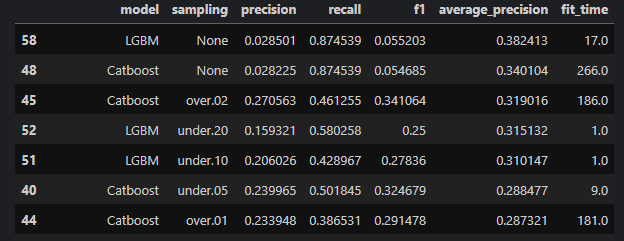

TOP-3 models are:
- LBGM balanced
- Catboost balanced
- XGBoost

## Hyperparameter Tuning

### Catboost tuning

In [24]:
def objective_catboost(trial):

    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),

        'depth': trial.suggest_int('depth', 4, 8),

        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15,log=True),

        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg', 1, 20, log=True),

        'random_strength': trial.suggest_float(
            'random_strength', 0.01, 5, log=True),

        'bagging_temperature': trial.suggest_float(
            'bagging_temperature', 0, 2),

        'auto_class_weights': 'Balanced',

        'loss_function': 'Logloss',

        # 'thread_count': 4,
        # 'used_ram_limit': '6gb',

        'random_seed': RANDOM_SEED,
        'verbose': False
    }


    model = CatBoostClassifier(**params)

    model.fit(
        X_train,
        y_train,

        cat_features=['type'],

        eval_set=(X_val, y_val),

        early_stopping_rounds=50,

        verbose=False
    )

    y_proba = model.predict_proba(X_val)[:, 1]

    return average_precision_score(
        y_val,
        y_proba
    )

study_catboost = optuna.create_study(
    direction='maximize',
)


study_catboost.optimize(
    objective_catboost,
    n_trials=20
)

[I 2026-08-18 19:07:15,580] A new study created in memory with name: no-name-e7979a7a-5004-41e4-a72a-9c0071179e60
[I 2026-08-18 19:08:53,120] Trial 0 finished with value: 0.35312605846886086 and parameters: {'iterations': 250, 'depth': 5, 'learning_rate': 0.022720593457981934, 'l2_leaf_reg': 12.876474796494222, 'random_strength': 0.03117936181183736, 'bagging_temperature': 1.6987720379988638}. Best is trial 0 with value: 0.35312605846886086.
[I 2026-08-18 19:10:43,024] Trial 1 finished with value: 0.3471676716978236 and parameters: {'iterations': 893, 'depth': 8, 'learning_rate': 0.027764590905333574, 'l2_leaf_reg': 3.3806832187098146, 'random_strength': 0.2502456257743115, 'bagging_temperature': 1.1979066570268788}. Best is trial 0 with value: 0.35312605846886086.
[I 2026-08-18 19:14:36,079] Trial 2 finished with value: 0.3151502830320223 and parameters: {'iterations': 508, 'depth': 4, 'learning_rate': 0.011760592198827212, 'l2_leaf_reg': 15.53263526667074, 'random_strength': 0.183181

In [25]:
catboost_model = CatBoostClassifier(**study_catboost.best_params)
joblib.dump(catboost_model, "../models/catboost_model.joblib")

### LightGBM tuning

In [29]:
def objective_lgbm(trial):

    params = {
        'objective': 'binary',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),

        'learning_rate': trial.suggest_float(
            'learning_rate', 0.01, 0.15, log=True),

        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 4, 12),

        'min_child_samples': trial.suggest_int(
            'min_child_samples', 20, 200),

        'subsample': trial.suggest_float(
            'subsample', 0.6, 1.0),

        'subsample_freq': 1,

        'reg_alpha': trial.suggest_float(
            'reg_alpha', 1e-8, 10.0, log=True),

        'reg_lambda': trial.suggest_float(
            'reg_lambda', 1e-8, 10.0, log=True),

        'class_weight': 'balanced',

        'n_jobs': 4,
        'random_state': RANDOM_SEED,
        'verbosity': -1
    }

    model = LGBMClassifier(**params)

    model.fit(
        X_train,
        y_train,
        categorical_feature=['type'],
        eval_X=X_val,
        eval_y=y_val,
        eval_metric='average_precision',
        callbacks=[
            lgb.early_stopping(50, verbose=False)
        ]
    )

    y_proba = model.predict_proba(X_val)[:, 1]

    return average_precision_score(
        y_val,
        y_proba
    )


study_lgbm = optuna.create_study(
    direction='maximize'
)

study_lgbm.optimize(
    objective_lgbm,
    n_trials=30
)

[I 2026-08-18 16:20:31,126] A new study created in memory with name: no-name-75dccabe-11ea-4ee0-8d87-73426378ebd4
[I 2026-08-18 16:20:57,870] Trial 0 finished with value: 0.22680347168852807 and parameters: {'n_estimators': 365, 'learning_rate': 0.09457718592000756, 'num_leaves': 64, 'max_depth': 8, 'min_child_samples': 145, 'subsample': 0.8656689681748246, 'reg_alpha': 8.075715601055849e-05, 'reg_lambda': 0.0002245997771040627}. Best is trial 0 with value: 0.22680347168852807.
[I 2026-08-18 16:21:29,938] Trial 1 finished with value: 0.3658100119649842 and parameters: {'n_estimators': 284, 'learning_rate': 0.02554944695952633, 'num_leaves': 75, 'max_depth': 6, 'min_child_samples': 102, 'subsample': 0.7680951281210047, 'reg_alpha': 0.004937538137679192, 'reg_lambda': 1.6321053905032168}. Best is trial 1 with value: 0.3658100119649842.
[I 2026-08-18 16:22:53,446] Trial 2 finished with value: 0.2766813334804608 and parameters: {'n_estimators': 544, 'learning_rate': 0.05683196310376317, 'n

In [30]:
lgbm_model = LGBMClassifier(**study_lgbm.best_params)
joblib.dump(lgbm_model, "../models/lgbm_model.joblib")

### XGBoost tuning

In [33]:
def objective_xgb(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),

        'learning_rate': trial.suggest_float(
            'learning_rate', 0.01, 0.15, log=True),

        'max_depth': trial.suggest_int(
            'max_depth', 3, 10),

        'min_child_weight': trial.suggest_float(
            'min_child_weight', 1, 20),

        'subsample': trial.suggest_float(
            'subsample', 0.6, 1.0),

        'colsample_bytree': trial.suggest_float(
            'colsample_bytree', 0.6, 1.0),

        'gamma': trial.suggest_float(
            'gamma', 0, 5),

        'reg_alpha': trial.suggest_float(
            'reg_alpha', 1e-8, 10, log=True),

        'reg_lambda': trial.suggest_float(
            'reg_lambda', 1e-8, 10, log=True),

        'enable_categorical': True,
        'eval_metric': 'aucpr',
        'n_jobs': 4,
        'random_state': RANDOM_SEED
    }

    model = XGBClassifier(**params)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_proba = model.predict_proba(X_val)[:, 1]

    return average_precision_score(
        y_val,
        y_proba
    )


study_xgb = optuna.create_study(
    direction='maximize'
)

study_xgb.optimize(
    objective_xgb,
    n_trials=20
)

[I 2026-08-18 16:36:04,822] A new study created in memory with name: no-name-c6b9f445-7db9-48ae-9ee0-aa4aa059531a
[I 2026-08-18 16:37:22,096] Trial 0 finished with value: 0.21050465837204946 and parameters: {'n_estimators': 139, 'learning_rate': 0.06441567637438547, 'max_depth': 7, 'min_child_weight': 10.812957162929221, 'subsample': 0.8374460800110932, 'colsample_bytree': 0.971273366765472, 'gamma': 2.644869887479595, 'reg_alpha': 7.887816329326289e-08, 'reg_lambda': 0.21538858760200047}. Best is trial 0 with value: 0.21050465837204946.
[I 2026-08-18 16:39:37,012] Trial 1 finished with value: 0.2618470606393657 and parameters: {'n_estimators': 361, 'learning_rate': 0.09559968262419259, 'max_depth': 6, 'min_child_weight': 17.621544144900756, 'subsample': 0.8390103716393701, 'colsample_bytree': 0.9879701382635828, 'gamma': 3.903221372982225, 'reg_alpha': 4.3569895466053365e-08, 'reg_lambda': 4.160702852681033e-05}. Best is trial 1 with value: 0.2618470606393657.
[I 2026-08-18 16:40:29,9

In [34]:
xgb_model = XGBClassifier(**study_xgb.best_params)
joblib.dump(xgb_model, "../models/xgb_model.joblib")